# Numerical Computation for Deep Learning — PyTorch edition

Quaderno didattico sulla **stabilità numerica nel deep learning**, costruito in riferimento alle slide *04_numerical.pptx* e alla traccia del notebook `numerical_errors.ipynb`.

## Obiettivi

Alla fine del notebook dovresti saper:

- distinguere **precisione** e **range dinamico** dei tipi floating point;
- riconoscere overflow, underflow, perdita di informazione e cancellazione catastrofica;
- capire perché formule matematicamente equivalenti possono comportarsi diversamente al computer;
- usare le primitive numericamente stabili di PyTorch (`logsumexp`, `log_softmax`, `cross_entropy`, `BCEWithLogitsLoss`, ...);
- diagnosticare `NaN`, `inf` e gradienti problematici;
- capire perché FP16/BF16 e mixed precision richiedono attenzioni specifiche.

> **Idea guida:** nel deep learning non basta che una formula sia matematicamente corretta. Deve anche essere implementata in modo stabile con un numero finito di bit.

## Mappa slide → PyTorch

| Tema | Versione ingenua / rischio | PyTorch consigliato |
|---|---|---|
| `log(sum(exp(x)))` | overflow / underflow | `torch.logsumexp` |
| `log(softmax(x))` | saturazione e `log(0)` | `F.log_softmax` |
| cross entropy multiclass | softmax → log → media | `F.cross_entropy` |
| binary cross entropy | sigmoid → BCE | `F.binary_cross_entropy_with_logits` / `nn.BCEWithLogitsLoss` |
| normalizzazione | divisione per deviazione standard quasi nulla | `sqrt(var + eps)` nelle normalizzazioni |
| mixed precision | underflow dei gradienti FP16 | `torch.autocast` + `torch.amp.GradScaler` |

La sequenza principale segue la parte delle slide dedicata a: precisione numerica → rounding → overflow/underflow → sottrazione → `log`/`sqrt` → log-sum-exp → softmax → cross-entropy → bug hunting.

## 0. Setup

In [1]:
import math
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

torch.manual_seed(0)

Python: 3.13.5
PyTorch: 2.10.0+cpu
CUDA available: False


## 1. Floating point: precisione e range dinamico

Un numero reale viene rappresentato con un numero finito di bit. Due proprietà sono particolarmente importanti:

- **precisione**: quanto finemente possiamo distinguere numeri vicini;
- **range dinamico**: quanto piccoli/grandi possono essere i numeri rappresentabili.

`torch.finfo` permette di ispezionare direttamente le proprietà numeriche di un dtype.

In [2]:
dtypes = [torch.float16, torch.bfloat16, torch.float32, torch.float64]

for dtype in dtypes:
    f = torch.finfo(dtype)
    print(
        f"{str(dtype):15s} "
        f"bits={f.bits:2d}  "
        f"eps={f.eps:.3e}  "
        f"tiny={f.tiny:.3e}  "
        f"max={f.max:.3e}"
    )

torch.float16   bits=16  eps=9.766e-04  tiny=6.104e-05  max=6.550e+04
torch.bfloat16  bits=16  eps=7.812e-03  tiny=1.175e-38  max=3.390e+38
torch.float32   bits=32  eps=1.192e-07  tiny=1.175e-38  max=3.403e+38
torch.float64   bits=64  eps=2.220e-16  tiny=2.225e-308  max=1.798e+308


### Osservazione

`eps` è la distanza tra 1 e il successivo numero rappresentabile maggiore di 1. Non esiste quindi una “precisione assoluta” uniforme su tutta la retta reale: la distanza tra numeri rappresentabili cresce con la loro grandezza.

**Domanda:** perché BF16 ha un `eps` peggiore di FP16, ma un `max` enormemente più grande?

## 2. Rounding: aggiungere un numero piccolo può non cambiare nulla

Questo riprende direttamente l'esempio delle slide: in `float32`, `1 + 1e-8` può essere arrotondato esattamente a `1`.

In [3]:
a = torch.tensor([0.0, 1e-8], dtype=torch.float32)

print("a              =", a)
print("a + 1          =", a + 1.0)
print("(a + 1) - 1   =", (a + 1.0) - 1.0)

a              = tensor([0.0000e+00, 1.0000e-08])
a + 1          = tensor([1., 1.])
(a + 1) - 1   = tensor([0., 0.])


L'ultima riga è la più importante: dopo l'arrotondamento, l'informazione sul termine piccolo **non è recuperabile**.

In [4]:
for dtype in [torch.float16, torch.bfloat16, torch.float32, torch.float64]:
    x = torch.tensor(1e-8, dtype=dtype)
    one = torch.tensor(1.0, dtype=dtype)
    print(dtype, "x =", x.item(), "  1+x =", (one + x).item())

torch.float16 x = 0.0   1+x = 1.0
torch.bfloat16 x = 1.0011717677116394e-08   1+x = 1.0
torch.float32 x = 9.99999993922529e-09   1+x = 1.0
torch.float64 x = 1e-08   1+x = 1.00000001


## 3. L'aritmetica floating point non è associativa

Nei reali:

\[
(a+b)+c = a+(b+c)
\]

In floating point, non necessariamente.

In [5]:
a = torch.tensor(1e8, dtype=torch.float32)
b = torch.tensor(-1e8, dtype=torch.float32)
c = torch.tensor(1.0, dtype=torch.float32)

left = (a + b) + c
right = a + (b + c)

print("(a+b)+c =", left.item())
print("a+(b+c) =", right.item())

(a+b)+c = 1.0
a+(b+c) = 0.0


Questo spiega perché riduzioni, parallelizzazione e backend diversi possono produrre piccole differenze anche a parità di input.

### Mini-esperimento: ordine della somma

In [6]:
x = torch.cat([
    torch.tensor([1e8], dtype=torch.float32),
    torch.ones(100_000, dtype=torch.float32),
    torch.tensor([-1e8], dtype=torch.float32),
])

print("torch.sum float32:", x.sum().item())
print("sum after float64 cast:", x.double().sum().item())

torch.sum float32: 99992.0
sum after float64 cast: 100000.0


## 4. Overflow e underflow di `exp`

Le slide evidenziano che `exp(x)` va in overflow già intorno a 89 in float32. Invece di memorizzare il numero, possiamo ricavare il limite dal dtype:

\[
\exp(x) \leq \text{finfo.max} \quad\Rightarrow\quad x \lesssim \log(\text{finfo.max})
\]

In [7]:
for dtype in [torch.float16, torch.bfloat16, torch.float32, torch.float64]:
    f = torch.finfo(dtype)
    print(dtype, "log(max) ≈", math.log(f.max))

torch.float16 log(max) ≈ 11.089866488461016
torch.bfloat16 log(max) ≈ 88.71892521235186
torch.float32 log(max) ≈ 88.72283905206835
torch.float64 log(max) ≈ 709.782712893384


In [8]:
values = torch.tensor([10.0, 12.0, 80.0, 89.0, 100.0])

for dtype in [torch.float16, torch.float32, torch.float64]:
    print("\n", dtype)
    print(torch.exp(values.to(dtype)))


 torch.float16
tensor([22032.,    inf,    inf,    inf,    inf], dtype=torch.float16)

 torch.float32
tensor([2.2026e+04, 1.6275e+05, 5.5406e+34,        inf,        inf])

 torch.float64
tensor([2.2026e+04, 1.6275e+05, 5.5406e+34, 4.4896e+38, 2.6881e+43],
       dtype=torch.float64)


### Underflow

Per valori molto negativi, `exp(x)` diventa così piccolo da essere arrotondato a zero.

In [9]:
values = torch.tensor([-10.0, -50.0, -100.0, -1000.0])

for dtype in [torch.float16, torch.float32, torch.float64]:
    print("\n", dtype)
    print(torch.exp(values.to(dtype)))


 torch.float16
tensor([4.5419e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00], dtype=torch.float16)

 torch.float32
tensor([4.5400e-05, 1.9287e-22, 3.7835e-44, 0.0000e+00])

 torch.float64
tensor([4.5400e-05, 1.9287e-22, 3.7201e-44, 0.0000e+00], dtype=torch.float64)


## 5. Effetti secondari: da `inf` a `NaN`

Un overflow non rimane necessariamente confinato all'operazione che lo ha prodotto.

In [10]:
x = torch.exp(torch.tensor(100.0, dtype=torch.float32))
y = torch.exp(torch.tensor(100.0, dtype=torch.float32))
z = x - y

print("x =", x)
print("y =", y)
print("x-y =", z)
print("isfinite?", torch.isfinite(z).item())

x = tensor(inf)
y = tensor(inf)
x-y = tensor(nan)
isfinite? False


`inf - inf` non ha un valore ben definito e produce `NaN`. Questo è un pattern tipico: l'operazione che genera il `NaN` può trovarsi **molto dopo** l'operazione che ha causato l'overflow iniziale.

## 6. Cancellazione catastrofica: il caso della varianza

Una formula matematicamente valida per la varianza è

\[
\operatorname{Var}(X) = E[X^2] - E[X]^2.
\]

Se i due termini sono grandi e quasi uguali, la sottrazione può cancellare molte cifre significative.

In [11]:
x = 1000.0 + 0.1 * torch.arange(10, dtype=torch.float32)

var_naive = (x * x).mean() - x.mean() ** 2
var_torch = torch.var(x, correction=0)
var_centered = ((x - x.mean()) ** 2).mean()

print("naive E[x²]-E[x]² =", var_naive)
print("centered form       =", var_centered)
print("torch.var           =", var_torch)

naive E[x²]-E[x]² = tensor(-0.0625)
centered form       = tensor(0.0825)
torch.var           = tensor(0.0825)


In [12]:
print("sqrt(naive variance) =", torch.sqrt(var_naive))
print("sqrt(torch variance) =", torch.sqrt(var_torch))

sqrt(naive variance) = tensor(nan)
sqrt(torch variance) = tensor(0.2872)


Questo esempio collega tre problemi delle slide:

1. sottrazione tra quantità di magnitudine simile;
2. varianza che può diventare numericamente errata;
3. `sqrt` di un numero negativo → `NaN`.

### Confronto con float64

In [13]:
x64 = x.double()
var_naive64 = (x64 * x64).mean() - x64.mean() ** 2
print("naive float64 =", var_naive64)

naive float64 = tensor(0.0825, dtype=torch.float64)


## 7. `log` e `sqrt`: dominio e derivate problematiche

- `log(0) = -inf`;
- `log(x<0)` produce `NaN` nei reali;
- `sqrt(0)=0`, ma la derivata \(1/(2\sqrt{x})\) diverge in zero.

In [14]:
vals = torch.tensor([1.0, 0.0, -1.0], dtype=torch.float32)
print("log :", torch.log(vals))
print("sqrt:", torch.sqrt(vals))

log : tensor([0., -inf, nan])
sqrt: tensor([1., 0., nan])


### Autograd rende visibile il problema della derivata di `sqrt`

In [15]:
x = torch.tensor(0.0, requires_grad=True)
y = torch.sqrt(x)
y.backward()

print("sqrt(0) =", y.item())
print("gradient =", x.grad)

sqrt(0) = 0.0
gradient = tensor(inf)


In [16]:
x = torch.tensor(0.0, requires_grad=True)
eps = 1e-6
y = torch.sqrt(x + eps)
y.backward()

print("sqrt(eps) =", y.item())
print("gradient   =", x.grad.item())

sqrt(eps) = 0.0010000000474974513
gradient   = 499.9999694824219


## 8. Dove mettere `eps`?

Le slide pongono la domanda:

```python
sqrt(variance + eps)
```

oppure

```python
sqrt(variance) + eps
```

Le due espressioni **non sono equivalenti**. Nei layer di normalizzazione si usa tipicamente la prima forma, cioè `eps` dentro la radice.

In [17]:
variance = torch.tensor([0.0, 1e-12, 1e-8, 1e-4, 1.0])
eps = 1e-5

inside = torch.sqrt(variance + eps)
outside = torch.sqrt(variance) + eps

print(torch.stack([variance, inside, outside], dim=1))

tensor([[0.0000e+00, 3.1623e-03, 1.0000e-05],
        [1.0000e-12, 3.1623e-03, 1.1000e-05],
        [1.0000e-08, 3.1639e-03, 1.1000e-04],
        [1.0000e-04, 1.0488e-02, 1.0010e-02],
        [1.0000e+00, 1.0000e+00, 1.0000e+00]])


Quando la varianza è piccola, la posizione di `eps` cambia sensibilmente il denominatore e quindi la funzione implementata.

## 9. Funzioni specializzate: `log1p` ed `expm1`

Per piccoli \(x\), calcolare prima `1+x` può perdere completamente l'incremento. Per questo esistono primitive dedicate:

- `torch.log1p(x)` calcola \(\log(1+x)\);
- `torch.expm1(x)` calcola \(e^x-1\).

In [18]:
x = torch.tensor(1e-8, dtype=torch.float32)

print("torch.log(1+x) =", torch.log(1 + x).item())
print("torch.log1p(x)  =", torch.log1p(x).item())
print()
print("torch.exp(x)-1  =", (torch.exp(x) - 1).item())
print("torch.expm1(x)  =", torch.expm1(x).item())

torch.log(1+x) = 0.0
torch.log1p(x)  = 9.99999993922529e-09

torch.exp(x)-1  = 0.0
torch.expm1(x)  = 9.99999993922529e-09


### Visualizzazione dell’errore per `log(1+x)`

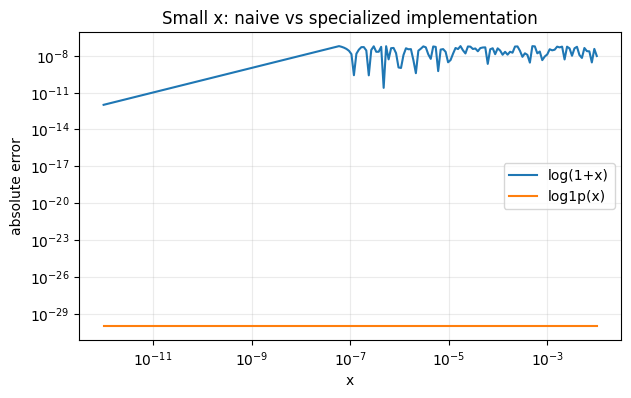

In [19]:
xs = torch.logspace(-12, -2, 200, dtype=torch.float32)
naive = torch.log(1 + xs)
stable = torch.log1p(xs)
reference = torch.log1p(xs.double()).float()

err_naive = (naive - reference).abs()
err_stable = (stable - reference).abs()

plt.figure(figsize=(7, 4))
plt.loglog(xs.numpy(), (err_naive + 1e-30).numpy(), label="log(1+x)")
plt.loglog(xs.numpy(), (err_stable + 1e-30).numpy(), label="log1p(x)")
plt.xlabel("x")
plt.ylabel("absolute error")
plt.title("Small x: naive vs specialized implementation")
plt.legend()
plt.grid(True, which="both", alpha=0.25)
plt.show()

## 10. `log(exp(x))` e Softplus

Le slide osservano che `log(exp(x))` dovrebbe essere semplificato a `x`. Il motivo non è solo l'efficienza: l'intermedio `exp(x)` può andare in overflow.

In [20]:
for value in [1.0, 50.0, 100.0, -100.0]:
    x = torch.tensor(value, dtype=torch.float32)
    naive = torch.log(torch.exp(x))
    print(f"x={value:7.1f}  log(exp(x))={naive.item():>12}  stable={x.item():>8}")

x=    1.0  log(exp(x))=         1.0  stable=     1.0
x=   50.0  log(exp(x))=        50.0  stable=    50.0
x=  100.0  log(exp(x))=         inf  stable=   100.0
x= -100.0  log(exp(x))=-99.98309326171875  stable=  -100.0


### Softplus

\[
\operatorname{softplus}(x)=\log(1+e^x)
\]

È un esempio perfetto di formula semplice che richiede un'implementazione stabile.

In [21]:
x = torch.tensor([10.0, 50.0, 100.0], dtype=torch.float32)

naive = torch.log(1 + torch.exp(x))
stable = F.softplus(x)

print("naive :", naive)
print("stable:", stable)

naive : tensor([10.0000, 50.0000,     inf])
stable: tensor([ 10.0000,  50.0000, 100.0000])


# Parte II — Stabilità delle funzioni di probabilità e delle loss

Questa è la parte più importante per il deep learning pratico: molte loss combinano `exp`, normalizzazioni e `log`.

## 11. LogSumExp

La forma ingenua

\[
\log \sum_i e^{x_i}
\]

fallisce se un elemento è molto grande (overflow) o se tutti sono molto negativi (underflow).

La trasformazione stabile usa \(m=\max_i x_i\):

\[
\log\sum_i e^{x_i} = m + \log\sum_i e^{x_i-m}.
\]

In [22]:
def naive_logsumexp(x, dim=0):
    return torch.log(torch.exp(x).sum(dim=dim))


def stable_logsumexp_manual(x, dim=0):
    m = x.max(dim=dim, keepdim=True).values
    return (m + torch.log(torch.exp(x - m).sum(dim=dim, keepdim=True))).squeeze(dim)

for x in [
    torch.tensor([1000.0, 1000.0]),
    torch.tensor([-1000.0, -1000.0]),
]:
    print("x =", x.tolist())
    print("naive  =", naive_logsumexp(x))
    print("manual =", stable_logsumexp_manual(x))
    print("torch   =", torch.logsumexp(x, dim=0))
    print()

x = [1000.0, 1000.0]
naive  = tensor(inf)
manual = tensor(1000.6932)
torch   = tensor(1000.6932)

x = [-1000.0, -1000.0]
naive  = tensor(-inf)
manual = tensor(-999.3068)
torch   = tensor(-999.3068)



## 12. Softmax ingenua vs stabile

Una implementazione letterale della formula

\[
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
\]

può produrre `inf/inf`.

In [23]:
def softmax_naive(x, dim=-1):
    e = torch.exp(x)
    return e / e.sum(dim=dim, keepdim=True)


def softmax_stable_manual(x, dim=-1):
    z = x - x.max(dim=dim, keepdim=True).values
    e = torch.exp(z)
    return e / e.sum(dim=dim, keepdim=True)

logits = torch.tensor([[1000.0, 999.0, 998.0]])

print("naive :", softmax_naive(logits, dim=1))
print("manual:", softmax_stable_manual(logits, dim=1))
print("F.softmax:", F.softmax(logits, dim=1))

naive : tensor([[nan, nan, nan]])
manual: tensor([[0.6652, 0.2447, 0.0900]])
F.softmax: tensor([[0.6652, 0.2447, 0.0900]])


## 13. `log(softmax(x))` vs `log_softmax(x)`

Questa è una delle sostituzioni più importanti in PyTorch.

In [24]:
logits = torch.tensor([[1000.0, 0.0, -1000.0]])

bad = torch.log(F.softmax(logits, dim=1))
good = F.log_softmax(logits, dim=1)

print("log(softmax):", bad)
print("log_softmax :", good)

log(softmax): tensor([[0., -inf, -inf]])
log_softmax : tensor([[    0., -1000., -2000.]])


La probabilità della classe improbabile può essere arrotondata a zero; dopo questo passaggio `log(0)` è irrimediabilmente `-inf`. `log_softmax` evita di materializzare quella probabilità estrema nel modo ingenuo.

## 14. Cross-entropy: usare i logits, non le probabilità

Le slide sottolineano che la cross-entropy va calcolata direttamente dai logits.

### Implementazione ingenua

In [25]:
logits = torch.tensor([[1000.0, 0.0, -1000.0]], requires_grad=True)
target = torch.tensor([1])

p = F.softmax(logits, dim=1)
loss_bad = -torch.log(p[0, target[0]])

print("probabilities =", p)
print("loss_bad      =", loss_bad)

loss_bad.backward()
print("gradient bad  =", logits.grad)

probabilities = tensor([[1., 0., 0.]], grad_fn=<SoftmaxBackward0>)
loss_bad      = tensor(inf, grad_fn=<NegBackward0>)
gradient bad  = tensor([[nan, nan, nan]])


### Implementazione corretta con `F.cross_entropy`

In [26]:
logits = torch.tensor([[1000.0, 0.0, -1000.0]], requires_grad=True)
target = torch.tensor([1])

loss_good = F.cross_entropy(logits, target)
print("loss_good     =", loss_good)

loss_good.backward()
print("gradient good =", logits.grad)

loss_good     = tensor(1000., grad_fn=<NllLossBackward0>)
gradient good = tensor([[ 1., -1.,  0.]])


Il punto cruciale non è solo avere una loss finita: **serve un gradiente utilizzabile**.

## 15. Caso binario: Sigmoid + BCE vs BCEWithLogits

Lo stesso principio vale nel caso binario.

In [27]:
z = torch.tensor([100.0], requires_grad=True)
y = torch.tensor([0.0])

p = torch.sigmoid(z)
loss_bad = -(y * torch.log(p) + (1-y) * torch.log(1-p)).mean()

print("sigmoid(z) =", p)
print("manual BCE =", loss_bad)

loss_bad.backward()
print("bad grad   =", z.grad)

sigmoid(z) = tensor([1.], grad_fn=<SigmoidBackward0>)
manual BCE = tensor(inf, grad_fn=<NegBackward0>)
bad grad   = tensor([nan])


In [28]:
z = torch.tensor([100.0], requires_grad=True)
y = torch.tensor([0.0])

loss_good = F.binary_cross_entropy_with_logits(z, y)
print("BCEWithLogits =", loss_good)

loss_good.backward()
print("good grad     =", z.grad)

BCEWithLogits = tensor(100., grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
good grad     = tensor([1.])


**Regola pratica:**

- multiclass → `F.cross_entropy(logits, target)`;
- binary/multilabel → `F.binary_cross_entropy_with_logits(logits, target)` oppure `nn.BCEWithLogitsLoss`.

## 16. Esempio moderno: attention e softmax estrema

La scaled dot-product attention contiene una softmax:

\[
\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V.
\]

Con score molto grandi, una softmax implementata ingenuamente può fallire.

In [29]:
Q = torch.tensor([[1000.0, 1000.0], [1000.0, -1000.0]])
K = torch.tensor([[1000.0, 1000.0], [-1000.0, 1000.0]])
V = torch.tensor([[1.0, 0.0], [0.0, 1.0]])

scores = Q @ K.T / math.sqrt(Q.shape[-1])

weights_bad = softmax_naive(scores, dim=-1)
weights_good = F.softmax(scores, dim=-1)

print("scores:\n", scores)
print("\nnaive attention weights:\n", weights_bad)
print("\nstable attention weights:\n", weights_good)
print("\nstable attention output:\n", weights_good @ V)

scores:
 tensor([[ 1414213.6250,        0.0000],
        [       0.0000, -1414213.6250]])

naive attention weights:
 tensor([[nan, 0.],
        [1., 0.]])

stable attention weights:
 tensor([[1., 0.],
        [1., 0.]])

stable attention output:
 tensor([[1., 0.],
        [1., 0.]])


Questo collega direttamente la stabilità numerica ai Transformer: la softmax stabile non è un dettaglio “di basso livello”, ma una condizione necessaria per far funzionare blocchi fondamentali delle architetture moderne.

# Parte III — Precisione ridotta e mixed precision

## 17. FP16 vs BF16 vs FP32

FP16 e BF16 sacrificano bit rispetto a FP32, ma in modo diverso:

- FP16 ha maggiore precisione nella mantissa rispetto a BF16, ma range dinamico molto più piccolo;
- BF16 mantiene un range simile a FP32, ma ha precisione più grossolana.

In [30]:
values = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]

for v in values:
    row = []
    for dtype in [torch.float16, torch.bfloat16, torch.float32]:
        row.append(torch.tensor(v, dtype=dtype).item())
    print(f"{v:>8.1e}   fp16={row[0]:>12.4e}   bf16={row[1]:>12.4e}   fp32={row[2]:>12.4e}")

 1.0e-02   fp16=  1.0002e-02   bf16=  1.0010e-02   fp32=  1.0000e-02
 1.0e-04   fp16=  1.0002e-04   bf16=  1.0014e-04   fp32=  1.0000e-04
 1.0e-06   fp16=  1.0133e-06   bf16=  9.9838e-07   fp32=  1.0000e-06
 1.0e-08   fp16=  0.0000e+00   bf16=  1.0012e-08   fp32=  1.0000e-08
 1.0e-10   fp16=  0.0000e+00   bf16=  1.0004e-10   fp32=  1.0000e-10


### Esempio di gradiente che underflowa in FP16

In [31]:
g = torch.tensor([1e-8], dtype=torch.float32)
print("float32:", g)
print("float16:", g.to(torch.float16))
print("bfloat16:", g.to(torch.bfloat16))

float32: tensor([1.0000e-08])
float16: tensor([0.], dtype=torch.float16)
bfloat16: tensor([1.0012e-08], dtype=torch.bfloat16)


Questo è il motivo concettuale del **gradient scaling**: moltiplicare temporaneamente la loss sposta i gradienti verso magnitudini più rappresentabili durante il backward.

## 18. Automatic Mixed Precision (AMP)

Su GPU CUDA, il pattern moderno PyTorch è:

1. `torch.autocast` nel forward e nel calcolo della loss;
2. `torch.amp.GradScaler` per ridurre il rischio di underflow dei gradienti FP16;
3. backward fuori dal contesto `autocast`.

La cella seguente è eseguibile in Colab con runtime GPU; su CPU viene saltata.

In [32]:
if torch.cuda.is_available():
    device = "cuda"
    model = nn.Sequential(
        nn.Linear(32, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scaler = torch.amp.GradScaler("cuda")

    x = torch.randn(128, 32, device=device)
    target = torch.randint(0, 10, (128,), device=device)

    optimizer.zero_grad(set_to_none=True)

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        logits = model(x)
        loss = F.cross_entropy(logits, target)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    print("AMP step completed. loss =", loss.item())
else:
    print("CUDA non disponibile: cella AMP saltata. In Colab: Runtime → Change runtime type → GPU.")

CUDA non disponibile: cella AMP saltata. In Colab: Runtime → Change runtime type → GPU.


## 19. Il risultato finale può essere rappresentabile, ma gli intermedi no

È un errore comune pensare: “se il risultato è nel range di float32, allora il calcolo è sicuro”.

La norma euclidea contiene quadrati intermedi. Per componenti molto grandi, i quadrati possono overfloware anche se la norma finale sarebbe rappresentabile.

In [33]:
a = torch.tensor([1e20, 1e20], dtype=torch.float32)

print("float32 norm:", a.norm())
print("float64 norm:", a.double().norm())

float32 norm: tensor(inf)
float64 norm: tensor(1.4142e+20, dtype=torch.float64)


# Parte IV — Linear algebra e condizionamento

## 20. Matrici quasi singolari

La stabilità non dipende solo dal dtype: dipende anche dal **condizionamento del problema**. Una matrice quasi singolare amplifica piccoli errori nei dati e negli arrotondamenti.

In [34]:
A64 = torch.tensor([
    [1.0, 1.0],
    [1.0, 1.0 + 1e-7],
], dtype=torch.float64)
b64 = torch.tensor([2.0, 2.0 + 1e-7], dtype=torch.float64)

A32 = A64.float()
b32 = b64.float()

print("cond(A64) =", torch.linalg.cond(A64).item())
print("solution float64 =", torch.linalg.solve(A64, b64))

try:
    print("solution float32 =", torch.linalg.solve(A32, b32))
except RuntimeError as e:
    print("float32 solve failed:", e)

cond(A64) = 40000001.95305915
solution float64 = tensor([1.0000, 1.0000], dtype=torch.float64)
solution float32 = tensor([2., 0.])


### Piccola perturbazione dei dati

In [35]:
A = torch.tensor([
    [1.0, 1.0],
    [1.0, 1.0 + 1e-10],
], dtype=torch.float64)

b1 = torch.tensor([2.0, 2.0 + 1e-10], dtype=torch.float64)
b2 = b1.clone()
b2[1] += 1e-12

x1 = torch.linalg.solve(A, b1)
x2 = torch.linalg.solve(A, b2)

print("x1 =", x1)
print("x2 =", x2)
print("delta solution =", x2 - x1)
print("cond(A) =", torch.linalg.cond(A).item())

x1 = tensor([1., 1.], dtype=torch.float64)
x2 = tensor([0.9900, 1.0100], dtype=torch.float64)
delta solution = tensor([-0.0100,  0.0100], dtype=torch.float64)
cond(A) = 39999947702.450424


# Parte V — Debugging numerico in PyTorch

## 21. Controllare sistematicamente `NaN` e `inf`

In [36]:
def tensor_report(name, x):
    x_detached = x.detach()
    finite = torch.isfinite(x_detached)
    print(f"{name}")
    print("  shape    :", tuple(x_detached.shape))
    print("  dtype    :", x_detached.dtype)
    print("  allfinite:", finite.all().item())
    print("  nan      :", torch.isnan(x_detached).sum().item())
    print("  inf      :", torch.isinf(x_detached).sum().item())
    if finite.any():
        xf = x_detached[finite]
        print("  min/max  :", xf.min().item(), xf.max().item())

x = torch.tensor([1.0, float("inf"), float("nan")])
tensor_report("example", x)

example
  shape    : (3,)
  dtype    : torch.float32
  allfinite: False
  nan      : 1
  inf      : 1
  min/max  : 1.0 1.0


## 22. Controllare i gradienti durante il training

In [37]:
def report_nonfinite_gradients(model):
    bad = []
    for name, p in model.named_parameters():
        if p.grad is not None and not torch.isfinite(p.grad).all():
            bad.append(name)
    return bad

model = nn.Linear(4, 2)
x = torch.randn(8, 4)
y = torch.randint(0, 2, (8,))

loss = F.cross_entropy(model(x), y)
loss.backward()

print("non-finite gradients:", report_nonfinite_gradients(model))

non-finite gradients: []


## 23. `detect_anomaly`: localizzare operazioni problematiche nel backward

`torch.autograd.detect_anomaly()` è molto utile in debug, ma è costoso: non va lasciato attivo normalmente durante il training.

In [38]:
x = torch.tensor(0.0, requires_grad=True)

try:
    with torch.autograd.detect_anomaly():
        # 0/0 produce NaN nel forward e un backward problematico
        y = x / x
        y.backward()
except RuntimeError as e:
    print("Anomaly detected:")
    print(str(e).splitlines()[0])

Anomaly detected:
Function 'DivBackward0' returned nan values in its 1th output.


/tmp/ipykernel_904/324839533.py:4: UserWarning: Anomaly Detection has been enabled. This mode will increase the runtime and should only be enabled for debugging.
  with torch.autograd.detect_anomaly():
/opt/pyvenv/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: Error detected in DivBackward0. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/pyvenv/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/pyvenv/lib/python3.13/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/opt/pyvenv/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/opt/pyvenv/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3

## 24. `nan_to_num` non è una cura

`torch.nan_to_num` può essere utile per sanitizzare dati o output in casi controllati, ma **non deve nascondere una loss o un gradiente numericamente instabile**.

In [39]:
x = torch.tensor([1.0, float("nan"), float("inf"), -float("inf")])
print(torch.nan_to_num(x))

tensor([ 1.0000e+00,  0.0000e+00,  3.4028e+38, -3.4028e+38])


Se `NaN` compare durante il training, la priorità è trovare **la prima operazione che genera un valore non finito**, non sostituirlo alla fine della pipeline.

# Parte VI — Mini laboratorio: pipeline instabile vs stabile

Mettiamo insieme i concetti precedenti in un singolo esempio multiclass.

In [40]:
torch.manual_seed(1)

# Simuliamo logits molto grandi: situazione che può emergere da pesi/attivazioni esplosive.
logits = 200.0 * torch.randn(16, 5, requires_grad=True)
target = torch.randint(0, 5, (16,))

# Pipeline ingenua
p = softmax_naive(logits, dim=1)
loss_bad = -torch.log(p[torch.arange(len(target)), target]).mean()

print("bad loss:", loss_bad)
print("bad loss finite?", torch.isfinite(loss_bad).item())

bad loss: tensor(nan, grad_fn=<NegBackward0>)
bad loss finite? False


In [41]:
# Pipeline stabile
logits2 = logits.detach().clone().requires_grad_(True)
loss_good = F.cross_entropy(logits2, target)
loss_good.backward()

print("good loss:", loss_good)
print("good loss finite?", torch.isfinite(loss_good).item())
print("good gradients finite?", torch.isfinite(logits2.grad).all().item())

good loss: tensor(274.6981, grad_fn=<NllLossBackward0>)
good loss finite? True
good gradients finite? True


# Checklist pratica

Quando compaiono `NaN`, `inf`, loss bloccata o gradienti sospetti:

1. **Controlla il dtype** (`float16`, `bfloat16`, `float32`, `float64`).
2. Cerca `exp`, `log`, `sqrt`, divisioni e sottrazioni tra numeri simili.
3. Controlla gli intermedi con `torch.isfinite`.
4. Usa loss che lavorano direttamente sui **logits**.
5. Preferisci `torch.logsumexp`, `F.log_softmax`, `F.cross_entropy`, `BCEWithLogitsLoss` alle composizioni manuali.
6. Verifica se la normalizzazione ha un `eps` adeguato.
7. In FP16, considera underflow/overflow e usa AMP + gradient scaling.
8. Se il problema riguarda algebra lineare, controlla il **condition number**.
9. Usa `detect_anomaly()` temporaneamente per localizzare un backward problematico.
10. Non usare `nan_to_num` per mascherare una pipeline numericamente instabile.

# Esercizi

### Esercizio 1 — soglia di overflow
Scrivi una funzione che, dato un `torch.dtype`, stimi il massimo `x` per cui `exp(x)` rimane finito. Verifica sperimentalmente il risultato.

### Esercizio 2 — sommatoria
Costruisci un vettore contenente numeri molto grandi e numeri piccoli. Confronta `sum` in float32 e float64 e prova diversi ordinamenti degli elementi.

### Esercizio 3 — varianza
Genera dati della forma `offset + noise`, aumentando progressivamente `offset`. Confronta:

```python
(x*x).mean() - x.mean()**2
```

con `torch.var`.

### Esercizio 4 — cross entropy
Aumenta progressivamente la scala dei logits da 1 a 1000 e individua quando la pipeline `softmax -> log` inizia a produrre valori non finiti.

### Esercizio 5 — mixed precision
Su GPU, confronta un piccolo training loop in FP32 e con AMP. Registra loss, tempo e presenza di gradienti non finiti.

### Esercizio 6 — attention
Aumenta la norma di `Q` e `K` e confronta la softmax ingenua con `F.softmax`.

# Riferimenti

- Slide del corso: *04_numerical.pptx*, sezione **Numerical Precision: A deep learning super skill** e successive.
- Notebook di partenza indicato dal docente: `serivan/DeepLearning/02-Preliminaries/numerical_errors.ipynb`.
- PyTorch documentation: *Numerical accuracy*, `torch.finfo`, `torch.logsumexp`, `F.log_softmax`, `BCEWithLogitsLoss`, *Automatic Mixed Precision*.

> Nota: questa versione è una ricostruzione completa in PyTorch allineata ai contenuti delle slide. Non è una conversione meccanica cella-per-cella del notebook remoto.